## Raw data work

In [1]:
import gt_apps as my_apps

# 1. gtselect 설정
my_apps.filter['evclass'] = 1024       # GCE 분석을 위한 ULTRACLEANVETO 클래스
my_apps.filter['evtype'] = 3           # FRONT + BACK 데이터 모두 포함
my_apps.filter['ra'] = 266.4168        # 은하 중심 (Sgr A*) RA
my_apps.filter['dec'] = -29.0078       # 은하 중심 (Sgr A*) Dec
my_apps.filter['rad'] = 30             # 반경 30도
my_apps.filter['emin'] = 300           # 300 MeV (0.3 GeV) 이상
my_apps.filter['emax'] = 1000000       # 1 TeV 이하
my_apps.filter['zmax'] = 100            # 천정각 100도 컷 (대기 노이즈 차단)
my_apps.filter['tmin'] = 'INDEF'       # 다운로드 받은 시간 처음부터
my_apps.filter['tmax'] = 'INDEF'       # 끝까지
my_apps.filter['infile'] = '@events_12.txt'# 6개 파일이 묶인 리스트
my_apps.filter['outfile'] = 'GCE_12yr_filtered.fits'

print("Running gtselect... (데이터가 커서 몇 분 정도 소요될 수 있습니다)")
my_apps.filter.run()
print("gtselect 완료: GCE_12yr_filtered.fits 생성")

Running gtselect... (데이터가 커서 몇 분 정도 소요될 수 있습니다)
time -p gtselect infile=@events_12.txt outfile=GCE_12yr_filtered.fits ra=266.4168 dec=-29.0078 rad=30.0 tmin="INDEF" tmax="INDEF" emin=300.0 emax=1000000.0 zmin=0.0 zmax=100.0 evclass=1024 evtype=3 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=2 clobber=yes debug=no gui=no mode="ql"
Done.
real 135.65
user 125.48
sys 9.96
gtselect 완료: GCE_12yr_filtered.fits 생성


In [2]:
# 2. gtmktime 설정
my_apps.maketime['scfile'] = 'L2603260756186614_SC00.fits'  # Spacecraft 파일
my_apps.maketime['filter'] = '(DATA_QUAL>0)&&(LAT_CONFIG==1)' # 공식 표준 품질 필터
my_apps.maketime['roicut'] = 'no'                             # zmax 컷은 gtselect에서 이미 정교하게 함
my_apps.maketime['evfile'] = 'GCE_12yr_filtered.fits'         # 이전 단계의 출력물
my_apps.maketime['outfile'] = 'GCE_12yr_gti.fits'

print("Running gtmktime... (GTI 계산 중)")
my_apps.maketime.run()
print("gtmktime 완료: GCE_12yr_gti.fits 생성")

Running gtmktime... (GTI 계산 중)
time -p gtmktime scfile=L2603260756186614_SC00.fits sctable="SC_DATA" filter="(DATA_QUAL>0)&&(LAT_CONFIG==1)" roicut=no evfile=GCE_12yr_filtered.fits evtable="EVENTS" outfile="GCE_12yr_gti.fits" apply_filter=yes overwrite=no header_obstimes=yes tstart=0.0 tstop=0.0 gtifile="default" chatter=2 clobber=yes debug=no gui=no mode="ql"
real 318.73
user 308.40
sys 9.73
gtmktime 완료: GCE_12yr_gti.fits 생성


In [3]:
import gt_apps as my_apps

# =====================================================================
# 1. 3D Counts Map (CCUBE) 생성
# =====================================================================
my_apps.evtbin['algorithm'] = 'CCUBE'
my_apps.evtbin['evfile'] = 'GCE_12yr_gti.fits'              # 이전 단계에서 만든 깨끗한 데이터
my_apps.evtbin['outfile'] = 'GCE_12yr_ccube.fits'
my_apps.evtbin['scfile'] = 'L2603260756186614_SC00.fits'    # 우주선(Spacecraft) 파일

# 공간 Binning 설정 (40x40도 ROI 생성)
my_apps.evtbin['nxpix'] = 400       # 가로 픽셀 수 (400 * 0.1도 = 40도)
my_apps.evtbin['nypix'] = 400       # 세로 픽셀 수 (400 * 0.1도 = 40도)
my_apps.evtbin['binsz'] = 0.1       # 픽셀당 0.1도 (GCE 분석의 표준 해상도)
my_apps.evtbin['coordsys'] = 'GAL'  # 은하 좌표계
my_apps.evtbin['xref'] = 0.0        # 은하 중심 (l=0)
my_apps.evtbin['yref'] = 0.0        # 은하 중심 (b=0)
my_apps.evtbin['axisrot'] = 0.0
my_apps.evtbin['proj'] = 'CAR'      # 평면 투영 (Cartesian)

# 에너지 Binning 설정
my_apps.evtbin['ebinalg'] = 'LOG'
my_apps.evtbin['emin'] = 300        # 300 MeV
my_apps.evtbin['emax'] = 1000000    # 1 TeV
my_apps.evtbin['enumbins'] = 17     # 이전 실습과 동일하게 14개 또는 17개로 설정

print("1. Running gtbin (CCUBE 생성 중...)")
my_apps.evtbin.run()
print("✅ GCE_12yr_ccube.fits 생성 완료!")

# =====================================================================
# 2. Livetime Cube 생성 (가장 오래 걸리는 작업)
# =====================================================================
my_apps.expCube['evfile'] = 'GCE_12yr_gti.fits'
my_apps.expCube['scfile'] = 'L2603260756186614_SC00.fits'
my_apps.expCube['outfile'] = 'GCE_12yr_ltcube.fits'
my_apps.expCube['dcostheta'] = 0.025
my_apps.expCube['binsz'] = 1        # 기본값 1도 (라이브타임 큐브는 1도로 충분합니다)
my_apps.expCube['zmax'] = 100        # gtselect에서 설정한 zenith cut과 반드시 동일해야 함

print("\n2. Running gtltcube (Livetime 계산 중...)")
print("⚠️ 주의: 12년 치 데이터의 궤도를 적분하는 작업이므로 CPU 성능에 따라 수 시간~하루 이상 걸릴 수 있습니다.")
my_apps.expCube.run()
print("✅ GCE_12yr_ltcube.fits 생성 완료!")

1. Running gtbin (CCUBE 생성 중...)
time -p gtbin evfile=GCE_12yr_gti.fits scfile=L2603260756186614_SC00.fits outfile=GCE_12yr_ccube.fits algorithm="CCUBE" ebinalg="LOG" emin=300.0 emax=1000000.0 enumbins=17 ebinfile=NONE tbinalg="LIN" tbinfile=NONE nxpix=400 nypix=400 binsz=0.1 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 rafield="RA" decfield="DEC" proj="CAR" hpx_ordering_scheme="RING" hpx_order=3 hpx_ebin=yes hpx_region="" evtable="EVENTS" sctable="SC_DATA" efield="ENERGY" tfield="TIME" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbin version HEAD
real 13.06
user 11.67
sys 0.83
✅ GCE_12yr_ccube.fits 생성 완료!

2. Running gtltcube (Livetime 계산 중...)
⚠️ 주의: 12년 치 데이터의 궤도를 적분하는 작업이므로 CPU 성능에 따라 수 시간~하루 이상 걸릴 수 있습니다.
time -p gtltcube evfile="GCE_12yr_gti.fits" evtable="EVENTS" scfile=L2603260756186614_SC00.fits sctable="SC_DATA" outfile=GCE_12yr_ltcube.fits dcostheta=0.025 binsz=1.0 phibins=0 tmin=0.0 tmax=0.0 file_version="1" zmin=0.0 zmax=100.0 chatter=2 clobber=yes debug=no gu

In [33]:
%%bash
echo "Running gtexpcube2 (노출 지도 계산 중...)"

# Binned Exposure Cube 생성
gtexpcube2 \
    infile=GCE_12yr_ltcube.fits \
    cmap=GCE_12yr_ccube.fits \
    outfile=GCE_12yr_expcube.fits \
    irfs=P8R3_ULTRACLEANVETO_V3 \
    evtype=3 \
    chatter=2

echo "✅ GCE_12yr_expcube.fits 생성 완료!"

Running gtexpcube2 (노출 지도 계산 중...)


Computing binned exposure map....................!


Using evtype=3 (i.e., FRONT/BACK irfs)
✅ GCE_12yr_expcube.fits 생성 완료!


## Generate XML Model file

In [1]:
import os
import xml.etree.ElementTree as ET

# SourceList.py 파일 안의 SourceList 클래스를 직접 불러옵니다
from SourceList import SourceList 

# =====================================================================
# 1. 파일명 설정
# =====================================================================
catalog_file = 'gll_psc_v27.fit'                     # 4FGL-DR2 카탈로그

# [⭐핵심 수정⭐] ccube가 아닌 gti.fits(이벤트 리스트)를 넣어야 헤더를 정상적으로 읽습니다!
roi_file = 'GCE_12yr_gti.fits'                     

iso_file = 'iso_P8R3_CLEAN_V3_v1.txt'       
dummy_gal_file = 'gll_iem_v07.fits'                  

# [⭐핵심 수정⭐] 압축이 현재 폴더에 풀렸으므로, 확장 선원 디렉토리를 현재 폴더('.')로 지정합니다.
# SourceList 내부는 이 경로 하위의 'Templates/' 폴더를 찾게 설계되어 있습니다.
extended_dir = '.' 

# 기본 뼈대 XML 이름 변경
base_xml = 'GCE_12yr_4FGLDR2_base.xml'

# NAMING CONVENTION 파일 및 GDE 맵 폴더 경로
naming_conv_file = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat'
gde_dir = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/'

# =====================================================================
# 2. 기본 XML 뼈대 생성
# =====================================================================
if not os.path.exists(base_xml):
    print("4FGL-DR2 카탈로그를 로드하여 기본 XML 뼈대를 생성합니다 (최초 1회)...")
    
    # FL16Y(DR4)가 아닌 4FGL-DR2 양식에 맞게 DR=2 로 지정
    mymodel = SourceList(catalog_file, roi_file, base_xml, DR=2)
    
    # make_model 함수 호출 시 extended_directory 매개변수로 확장 선원 경로 전달
    mymodel.make_model(galactic_file=dummy_gal_file, 
                       galactic_name='gll_iem', 
                       isotropic_file=iso_file, 
                       isotropic_name='iso_p8v3',
                       extended_directory=extended_dir)
else:
    print(f"✅ 기존에 생성된 기본 뼈대({base_xml})를 재사용합니다.")

# =====================================================================
# 3. 모델 이름 규칙 파일 파싱 (80개 모델 목록 추출)
# =====================================================================
models_info = []
with open(naming_conv_file, 'r') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.split()
        if len(parts) >= 2:
            roman_name = parts[0]   
            folder_code = parts[1]  
            models_info.append((roman_name, folder_code))

print(f"총 {len(models_info)}개의 GDE 모델 XML을 일괄 생성합니다...\n")

# =====================================================================
# 4. 80개 모델에 대한 XML 자동 생성 루프
# =====================================================================
# 파일 관리를 위해 12년치 전용 폴더를 만들어 저장하는 것을 추천합니다.
out_xml_dir = 'XML_models_12yr'
if not os.path.exists(out_xml_dir):
    os.makedirs(out_xml_dir)

for roman_name, folder_code in models_info:
    # 저장되는 이름도 12yr, 4FGLDR2로 맞춰줍니다.
    final_xml = os.path.join(out_xml_dir, f'GCE_12yr_4FGLDR2_Model_{roman_name}.xml')
    
    # 뼈대 XML 파싱
    tree = ET.parse(base_xml)
    root = tree.getroot()

    # 더미 은하 배경(gll_iem) 블록 찾아서 삭제
    for source in root.findall('source'):
        if source.get('name') == 'gll_iem':
            root.remove(source)

    # 현재 루프의 모델(folder_code)에 맞는 GDE 맵 3종 세팅
    gde_components = [
        {'name': f'Pi0_Model{roman_name}',    'file': os.path.join(gde_dir, f'pi0_{folder_code}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits')},
        {'name': f'Bremss_Model{roman_name}', 'file': os.path.join(gde_dir, f'bremss_{folder_code}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits')},
        {'name': f'ICS_Model{roman_name}',    'file': os.path.join(gde_dir, f'ICS_{folder_code}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits')}
    ]

    # XML에 GDE 성분 주입
    for comp in gde_components:
        source = ET.SubElement(root, 'source', {'name': comp['name'], 'type': 'DiffuseSource'})
        
        spectrum = ET.SubElement(source, 'spectrum', {'type': 'ConstantValue'})
        ET.SubElement(spectrum, 'parameter', {'name': 'Value', 'value': '1.0', 'free': '1', 'max': '10.0', 'min': '0.1', 'scale': '1.0'})
        
        spatial = ET.SubElement(source, 'spatialModel', {'type': 'SpatialMap', 'file': comp['file']})
        ET.SubElement(spatial, 'parameter', {'name': 'Prefactor', 'value': '1.0', 'free': '0', 'max': '1000.0', 'min': '0.001', 'scale': '1.0'})

    # 최종 XML 저장
    tree.write(final_xml, encoding='utf-8', xml_declaration=True)
    
print("🎉 모든 GDE 모델(80개)에 대한 맞춤형 XML 파일 생성이 완료되었습니다!")

✅ 기존에 생성된 기본 뼈대(GCE_12yr_4FGLDR2_base.xml)를 재사용합니다.
총 80개의 GDE 모델 XML을 일괄 생성합니다...

🎉 모든 GDE 모델(80개)에 대한 맞춤형 XML 파일 생성이 완료되었습니다!


In [1]:
import glob
import xml.etree.ElementTree as ET

print("XML 파일들의 3D 큐브 파라미터 이름(Prefactor -> Normalization)을 수정합니다...")

xml_files = glob.glob('XML_models/*.xml')
count = 0

for xf in xml_files:
    tree = ET.parse(xf)
    root = tree.getroot()
    changed = False
    
    for source in root.findall('source'):
        spatial = source.find('spatialModel')
        # MapCubeFunction인 경우 내부 파라미터 확인
        if spatial is not None and spatial.get('type') == 'MapCubeFunction':
            for param in spatial.findall('parameter'):
                # Prefactor로 잘못 적혀있다면 Normalization으로 강제 변경
                if param.get('name') == 'Prefactor':
                    param.set('name', 'Normalization')
                    changed = True
                    
    if changed:
        tree.write(xf, encoding='utf-8', xml_declaration=True)
        count += 1

print(f"✅ 총 {count}개의 XML 파일 수정 완료! 이제 완벽합니다.")

XML 파일들의 3D 큐브 파라미터 이름(Prefactor -> Normalization)을 수정합니다...
✅ 총 80개의 XML 파일 수정 완료! 이제 완벽합니다.


In [6]:
%%bash
echo "넓은 경계를 가진 12.5년 치 100x100도 노출 지도를 새로 계산합니다..."

gtexpcube2 \
    infile=GCE_12yr_ltcube.fits \
    cmap=none \
    outfile=GCE_12yr_expcube_large.fits \
    irfs=P8R3_ULTRACLEANVETO_V3 \
    evtype=3 \
    nxpix=200 \
    nypix=200 \
    binsz=0.5 \
    coordsys=GAL \
    xref=0 yref=0 proj=CAR \
    emin=300 \
    emax=1000000 \
    enumbins=17 \
    chatter=2

echo "✅ GCE_12yr_expcube_large.fits 생성 완료!"

넓은 경계를 가진 12.5년 치 100x100도 노출 지도를 새로 계산합니다...
Rotation angle of image axis, in degrees[0] 

Computing binned exposure map....................!


Using evtype=3 (i.e., FRONT/BACK irfs)


In [7]:
!ls -lh GCE_12yr_expcube_large.fits

-rw-rw-r-- 1 haebarg haebarg 3.9M Mar 27 01:41 GCE_12yr_expcube_large.fits


In [8]:
import glob
import xml.etree.ElementTree as ET

print("XML 파일 내의 확장 선원(Extended Sources) 템플릿 경로를 12.5년 치 환경에 맞게 수정합니다...")

# [⭐핵심 수정⭐] 12년 치 XML 폴더 지정
xml_files = glob.glob('XML_models_12yr/*.xml')
count = 0

for xf in xml_files:
    tree = ET.parse(xf)
    root = tree.getroot()
    changed = False
    
    for source in root.findall('source'):
        spatial = source.find('spatialModel')
        if spatial is not None:
            file_path = spatial.get('file')
            
            # file_path가 존재하고, 우리가 만든 GDE 맵(InnerGalaxy)이나 
            # 등방성/은하배경 맵이 아니면서, 확장 선원(.fits)인 경우를 찾습니다.
            if file_path and file_path.endswith('.fits') and 'InnerGalaxy' not in file_path and 'gll_iem' not in file_path:
                
                # 경로에 'Templates'가 빠져있다면 채워 넣습니다.
                if 'Templates' not in file_path:
                    # 파일 이름만 추출 (예: ./W44.fits -> W44.fits)
                    file_name = file_path.split('/')[-1]
                    
                    # 현재 디렉토리의 Templates 폴더를 가리키도록 올바른 경로로 수정
                    new_path = f"Templates/{file_name}"
                    spatial.set('file', new_path)
                    changed = True
                    
    if changed:
        tree.write(xf, encoding='utf-8', xml_declaration=True)
        count += 1

print(f"✅ 총 {count}개의 XML 파일 경로 수정 완료! 이제 진짜 완벽합니다.")

XML 파일 내의 확장 선원(Extended Sources) 템플릿 경로를 12.5년 치 환경에 맞게 수정합니다...
✅ 총 80개의 XML 파일 경로 수정 완료! 이제 진짜 완벽합니다.


In [9]:
import glob
import xml.etree.ElementTree as ET

print("XML 파일들의 3D 큐브 파라미터 이름(Prefactor -> Normalization)을 수정합니다...")

# 12년 치 폴더 지정
xml_files = glob.glob('XML_models_12yr/*.xml')
count = 0

for xf in xml_files:
    tree = ET.parse(xf)
    root = tree.getroot()
    changed = False
    
    for source in root.findall('source'):
        spatial = source.find('spatialModel')
        # MapCubeFunction인 경우 내부 파라미터 확인
        if spatial is not None and spatial.get('type') == 'MapCubeFunction':
            for param in spatial.findall('parameter'):
                # Prefactor로 적혀있다면 Normalization으로 강제 변경
                if param.get('name') == 'Prefactor':
                    param.set('name', 'Normalization')
                    changed = True
                    
    if changed:
        tree.write(xf, encoding='utf-8', xml_declaration=True)
        count += 1

print(f"✅ 총 {count}개의 XML 파일 수정 완료! 이제 완벽합니다.")

XML 파일들의 3D 큐브 파라미터 이름(Prefactor -> Normalization)을 수정합니다...
✅ 총 80개의 XML 파일 수정 완료! 이제 완벽합니다.


In [10]:
# do not run in jupyter의 %%bash가 아닌, 순수 Python 코드로 실행합니다.
import os
import multiprocessing as mp
import time

def run_perfect_srcmaps(roman_name):
    import gt_apps as my_apps
    
    # 12년 치 전용 폴더 설정
    xml_dir = 'XML_models_12yr'
    srcmap_dir = 'Source_Maps_12yr' 
    
    if not os.path.exists(srcmap_dir):
        os.makedirs(srcmap_dir, exist_ok=True)
        
    xml_file = os.path.join(xml_dir, f'GCE_12yr_4FGLDR2_Model_{roman_name}.xml')
    outfile = os.path.join(srcmap_dir, f'GCE_12yr_srcmap_Model_{roman_name}.fits')
    
    # 이미 잘 구워진 파일은 건너뜀 (대략 30MB 이상)
    if os.path.exists(outfile) and os.path.getsize(outfile) > 30000000:
        return (roman_name, "이미 존재함 (건너뜀)")
        
    try:
        my_apps.srcMaps['expcube'] = 'GCE_12yr_ltcube.fits'          
        my_apps.srcMaps['cmap']    = 'GCE_12yr_ccube.fits'              
        my_apps.srcMaps['srcmdl']  = xml_file           
        my_apps.srcMaps['bexpmap'] = 'GCE_12yr_expcube_large.fits'         
        my_apps.srcMaps['outfile'] = outfile  
        my_apps.srcMaps['irfs']    = 'P8R3_ULTRACLEANVETO_V3'           
        my_apps.srcMaps['evtype']  = 3                                
        
        # ⭐ 점광원까지 모조리 FITS 파일 안에 구워 넣습니다!
        my_apps.srcMaps['ptsrc']   = 'yes'  
        my_apps.srcMaps['chatter'] = 0

        my_apps.srcMaps.run()
        return (roman_name, "✅ 생성 성공")
    except Exception as e:
        return (roman_name, f"❌ 에러 발생: {e}")

if __name__ == '__main__':
    start_time = time.time()
    
    naming_conv_file = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat'
    models_info = []
    with open(naming_conv_file, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 2:
                models_info.append(parts[0])

    NUM_CORES = 4
    print(f"▶️ 80개 12.5년 치 모델의 Source Maps 병렬 생성을 시작합니다. (코어: {NUM_CORES})")
    print("--------------------------------------------------")

    with mp.Pool(processes=NUM_CORES) as pool:
        for result in pool.imap_unordered(run_perfect_srcmaps, models_info):
            print(f"Model {result[0]} : {result[1]}")

    end_time = time.time()
    print(f"\n🎉 소스 맵 병렬 생성 완료! (소요 시간: {(end_time - start_time)/3600:.2f} 시간)")

▶️ 80개 12.5년 치 모델의 Source Maps 병렬 생성을 시작합니다. (코어: 4)
--------------------------------------------------


KeyboardInterrupt: 

In [ ]:
import os
from BinnedAnalysis import *

# =====================================================================
# 1. 폴더 및 파일 설정
# =====================================================================
xml_dir = 'XML_models_12yr'                 # 12.5년 치 XML 폴더
srcmap_dir = 'Source_Maps_12yr'             # 방금 정리한 소스 맵 폴더
fit_xml_dir = 'Fitted_XML_models_12yr'      # 피팅이 완료된 파라미터가 저장될 새 폴더

if not os.path.exists(fit_xml_dir):
    os.makedirs(fit_xml_dir)

naming_conv_file = '/home/haebarg/GCE-Chi-square-fitting/GCE_TEMPLATES_FILES_v3/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat'
models_info = []
with open(naming_conv_file, 'r') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.split()
        if len(parts) >= 2:
            models_info.append(parts[0])

# 최종 결과(우도 값)를 저장할 CSV 파일
results_file = 'Likelihood_Results_12yr.csv'
with open(results_file, 'w') as f:
    f.write("Model,LogLikelihood\n")

print("▶️ 80개 모델(12.5년 치)에 대한 Binned Likelihood Fitting을 시작합니다...\n")

# =====================================================================
# 2. 80개 모델 자동 피팅 루프
# =====================================================================
for roman_name in models_info:
    # 12.5년 치 + 4FGL-DR2 이름 규칙 적용
    xml_file = os.path.join(xml_dir, f'GCE_12yr_4FGLDR2_Model_{roman_name}.xml')
    srcmap_file = os.path.join(srcmap_dir, f'GCE_12yr_srcmap_Model_{roman_name}.fits')
    out_xml_file = os.path.join(fit_xml_dir, f'GCE_12yr_fitted_Model_{roman_name}.xml')

    if not os.path.exists(srcmap_file):
        print(f"⚠️ {srcmap_file} 이(가) 없어 건너뜁니다.")
        continue

    print(f"========================================")
    print(f"🚀 피팅 시작: Model {roman_name}")
    print(f"========================================")

    try:
        # 1. BinnedObs 객체 로드 (12.5년 치 데이터, 소스맵, 노출지도 묶기)
        obs = BinnedObs(srcMaps=srcmap_file,
                        expCube='GCE_12yr_ltcube.fits',
                        binnedExpMap='GCE_12yr_expcube_large.fits',
                        irfs='P8R3_ULTRACLEANVETO_V3')

        # 2. Likelihood 최적화 객체 생성 (NewMinuit 알고리즘 사용)
        like = BinnedAnalysis(obs, srcModel=xml_file, optimizer='NewMinuit')

        # 3. 우도 피팅 수행 (서버 성능에 따라 모델당 십여 분~수 시간 소요)
        likeObj = like.fit(covar=True, tol=1e-2, verbosity=0)

        # 4. 피팅된 최종 Log-Likelihood 값 추출
        logL = like.logLike.value()
        print(f"  ✅ 피팅 성공! -log(L) = {logL}")

        # 5. 최적화된 변수들이 기록된 새 XML 파일 저장
        like.logLike.writeXml(out_xml_file)

        # 6. CSV 파일에 결과 기록 (중간에 끊겨도 데이터가 남도록 바로바로 저장)
        with open(results_file, 'a') as f:
            f.write(f"{roman_name},{logL}\n")

    except Exception as e:
        print(f"  ❌ 에러 발생 (Model {roman_name}): {e}")

print("\n🎉 12.5년 치 데이터의 모든 우도 피팅이 완료되었습니다! CSV 결과를 확인하세요.")

In [ ]:
import gt_apps as my_apps

# 12.5년 치 데이터 파일들 세팅
my_apps.model_map['expcube'] = 'GCE_12yr_ltcube.fits'
my_apps.model_map['srcmaps'] = 'Source_Maps_12yr/GCE_12yr_srcmap_Model_I.fits'
my_apps.model_map['bexpmap'] = 'GCE_12yr_expcube_large.fits'

# 피팅이 완료된 XML 파일이 있다면 'Fitted_XML_models_12yr' 경로의 파일을,
# 아직 피팅 전이라면 'XML_models_12yr' 폴더의 파일을 사용하세요.
my_apps.model_map['srcmdl'] = 'XML_models_12yr/GCE_12yr_4FGLDR2_Model_I.xml' 

my_apps.model_map['outfile'] = 'GCE_12yr_Model_I_map.fits'
my_apps.model_map['irfs'] = 'P8R3_ULTRACLEANVETO_V3'
my_apps.model_map['evtype'] = 3

# 출력 형태를 3D Counts Cube와 동일하게 맞춰줍니다.
my_apps.model_map['outtype'] = 'ccube' 

print("Running gtmodel... (모델 맵 생성 중)")
my_apps.model_map.run()
print("✅ GCE_12yr_Model_I_map.fits 생성 완료!")

Running gtmodel... (모델 맵 생성 중)
time -p gtmodel srcmaps=Source_Maps_12yr/GCE_12yr_srcmap_Model_I.fits srcmdl=XML_models_12yr/GCE_12yr_4FGLDR2_Model_I.xml outfile=GCE_12yr_Model_I_map.fits irfs="P8R3_ULTRACLEANVETO_V3" evtype=3 expcube=GCE_12yr_ltcube.fits bexpmap=GCE_12yr_expcube_large.fits convol=yes resample=yes rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_bins=0 chatter=2 clobber=yes debug=no gui=no mode="ql"
Generating SourceMap for 4FGL J1438.5-4207 18....................!
Generating SourceMap for 4FGL J1439.9-3953 18....................!
Generating SourceMap for 4FGL J1440.6-3846 18....................!
Generating SourceMap for 4FGL J1442.1-3707 18....................!
Generating SourceMap for 4FGL J1442.6-4623 18....................!
Generating SourceMap for 4FGL J1443.9-3908 18....................!
Generating SourceMap for 4FGL J1446.0-3039 18....................!
Generating SourceMap for 4FGL J1446.6-4701 18....................!
Generating SourceMap for 4FGL J

: 

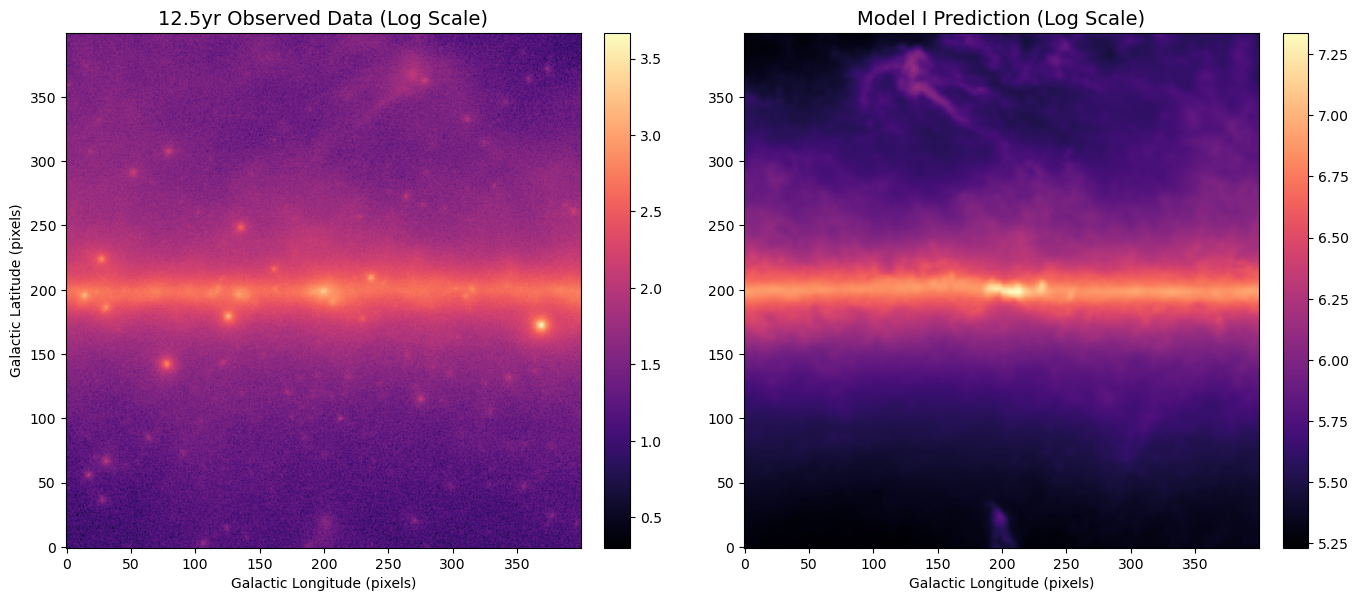

In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

# 1. 실제 관측 데이터 (Data Map)
data_hdul = fits.open('GCE_12yr_ccube.fits')
data_cube = data_hdul[0].data
# 3D 큐브의 0번째 축(에너지)을 기준으로 합산하여 2D 맵 생성
data_map2d = np.sum(data_cube, axis=0) 

# 2. 방금 생성한 모델 예측 맵 (Model Map)
model_hdul = fits.open('GCE_12yr_Model_I_map.fits')
model_cube = model_hdul[0].data
model_map2d = np.sum(model_cube, axis=0)

# 3. 시각화 (Log Scale 적용)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 데이터 맵 플롯
im1 = axes[0].imshow(np.log10(data_map2d + 1), origin='lower', cmap='magma')
axes[0].set_title('12.5yr Observed Data (Log Scale)', fontsize=14)
axes[0].set_xlabel('Galactic Longitude (pixels)')
axes[0].set_ylabel('Galactic Latitude (pixels)')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# 모델 맵 플롯
im2 = axes[1].imshow(np.log10(model_map2d + 1), origin='lower', cmap='magma')
axes[1].set_title('Model I Prediction (Log Scale)', fontsize=14)
axes[1].set_xlabel('Galactic Longitude (pixels)')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

print("논문(arXiv:2112.09706) 기준에 맞춰 은하 적도면 마스크를 생성합니다...")

# 1. 기준이 될 ccube 파일 로드
hdul = fits.open('GCE_12yr_ccube.fits')
cube = hdul[0].data
header = hdul[0].header

# 2. 공간 차원 정보 추출 (에너지 축 무시)
n_energy, ny, nx = cube.shape
w = WCS(header).celestial  # 2D 공간 좌표계만 추출

# 3. 픽셀 좌표를 은하 좌표(l, b)로 변환
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
lon, lat = w.pixel_to_world_values(X, Y)

# 4. 마스크 배열 생성 (초기값 1.0 = 연산 포함)
mask_2d = np.ones((ny, nx), dtype=np.float32)

# ==========================================================
# [마스킹 조건] 논문처럼 은하 적도면(|b| < 2.0도)을 0.0으로 덮습니다.
# ==========================================================
mask_2d[np.abs(lat) < 2.0] = 0.0

# 5. FITS 파일로 저장
mask_hdu = fits.PrimaryHDU(mask_2d, header=w.to_header())
mask_filename = 'GCE_12yr_mask_b2.fits'
mask_hdu.writeto(mask_filename, overwrite=True)

print(f"✅ 마스크 파일 생성 완료: {mask_filename}")

논문(arXiv:2112.09706) 기준에 맞춰 은하 적도면 마스크를 생성합니다...
✅ 마스크 파일 생성 완료: GCE_12yr_mask_b2.fits


Set MJD-END to 59249.655278 from DATE-END'. [astropy.wcs.wcs]


In [1]:
import numpy as np
from astropy.io import fits

# 1. 아까 만든 2D 마스크 파일 로드
mask_hdul = fits.open('GCE_12yr_mask_b2.fits')
mask_2d = mask_hdul[0].data

# 2. 유일한 관측 데이터 파일(ccube) 로드
ccube_file = 'GCE_12yr_ccube.fits'
print(f"[{ccube_file}] 파일에 마스크(WEIGHTS) 확장을 주입합니다...")

try:
    with fits.open(ccube_file, mode='update') as hdul:
        # ccube 파일의 첫 번째 블록(0번)이 3D 관측 데이터(COUNTS)입니다.
        counts_data = hdul[0].data
        n_energy, ny, nx = counts_data.shape
        
        # 2D 마스크(400x400)를 3D 에너지 층(17x400x400)으로 동일하게 확장
        mask_3d = np.broadcast_to(mask_2d, (n_energy, ny, nx))
        
        # 만약 이전 시도로 잘못 들어간 WEIGHTS가 있다면 삭제 (안전장치)
        if 'WEIGHTS' in hdul:
            print("⚠️ 기존 WEIGHTS 확장을 발견하여 새 마스크로 덮어씁니다.")
            del hdul['WEIGHTS']
            
        # Fermi Tools가 자동 인식하는 약속된 이름인 'WEIGHTS'로 HDU 생성
        weights_hdu = fits.ImageHDU(data=mask_3d.astype(np.float32), 
                                    header=hdul[0].header, 
                                    name='WEIGHTS')
        
        # 파일 꼬리에 덧붙이고 저장
        hdul.append(weights_hdu)
        hdul.flush()
        
    print("✅ 마스크 주입 성공! 이제 피팅 알고리즘이 은하 적도면(|b|<2도)을 완벽히 무시합니다.")
    
except Exception as e:
    print(f"❌ 에러 발생: {e}")

[GCE_12yr_ccube.fits] 파일에 마스크(WEIGHTS) 확장을 주입합니다...
⚠️ 기존 WEIGHTS 확장을 발견하여 새 마스크로 덮어씁니다.
✅ 마스크 주입 성공! 이제 피팅 알고리즘이 은하 적도면(|b|<2도)을 완벽히 무시합니다.


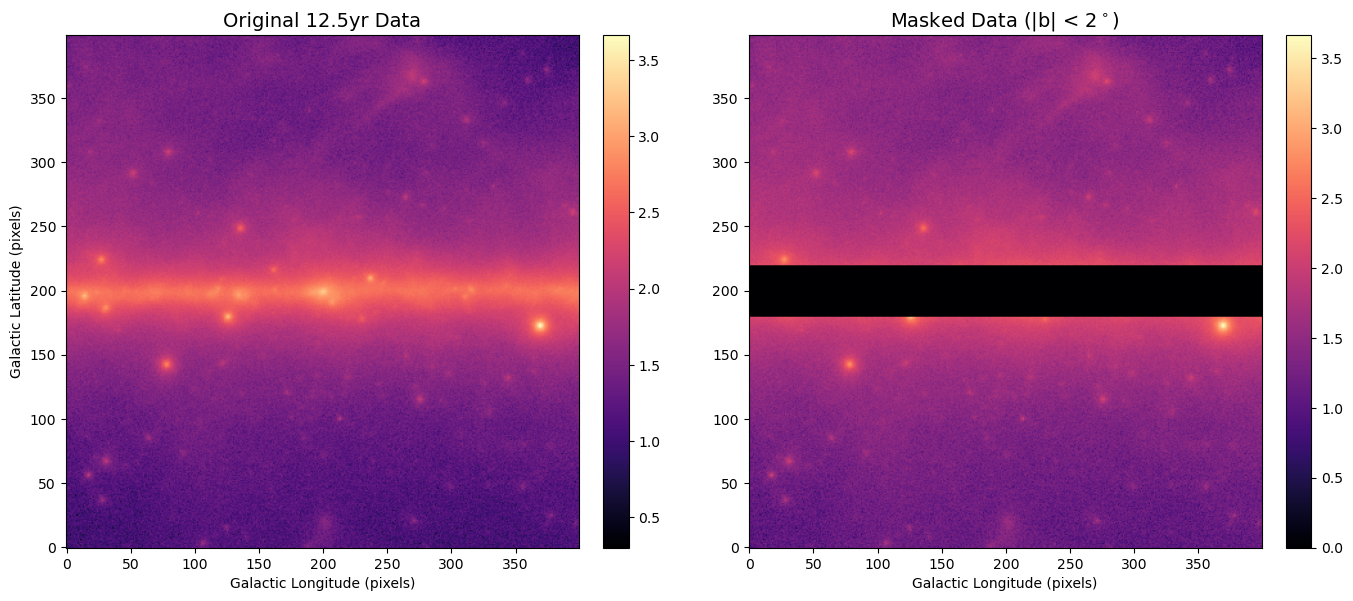

In [13]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

# 1. 실제 관측 데이터 (Data Map) 로드
data_hdul = fits.open('GCE_12yr_ccube.fits')
data_cube = data_hdul[0].data
data_map2d = np.sum(data_cube, axis=0)  # 에너지 축 합산

# 2. 우리가 만든 은하 적도면 마스크 로드
mask_hdul = fits.open('GCE_12yr_mask_b2.fits')
mask_2d = mask_hdul[0].data

# 3. 관측 데이터에 마스크 씌우기 (행렬 곱)
# 마스크 값이 0인 곳은 데이터도 0이 되고, 1인 곳은 그대로 남습니다.
masked_data_map2d = data_map2d * mask_2d

# 4. 시각화 (Log Scale 적용)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 원본 데이터 플롯
im1 = axes[0].imshow(np.log10(data_map2d + 1), origin='lower', cmap='magma')
axes[0].set_title('Original 12.5yr Data', fontsize=14)
axes[0].set_xlabel('Galactic Longitude (pixels)')
axes[0].set_ylabel('Galactic Latitude (pixels)')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# 마스킹된 데이터 플롯
im2 = axes[1].imshow(np.log10(masked_data_map2d + 1), origin='lower', cmap='magma')
axes[1].set_title('Masked Data (|b| < 2$^\circ$)', fontsize=14)
axes[1].set_xlabel('Galactic Longitude (pixels)')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [2]:
from astropy.io import fits

# 첫 번째 모델의 소스 맵 내부 블록 리스트 확인
hdul = fits.open('Source_Maps_12yr/GCE_12yr_srcmap_Model_I.fits')
hdul.info()

Filename: Source_Maps_12yr/GCE_12yr_srcmap_Model_I.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      62   (400, 400, 17)   float32   
  1  GTI           1 BinTableHDU     33   69696R x 2C   [D, D]   
  2  EBOUNDS       1 BinTableHDU     38   17R x 3C   [I, 1E, 1E]   


In [ ]:
import os
import subprocess
import multiprocessing as mp
import time

def generate_diffuse_srcmap(roman_name):
    xml_file = f'XML_models_12yr/GCE_12yr_4FGLDR2_Model_{roman_name}.xml'
    outfile = f'Source_Maps_12yr/GCE_12yr_srcmap_Model_{roman_name}.fits'

    cmd = [
        "gtsrcmaps",
        "expcube=GCE_12yr_ltcube.fits",
        "cmap=GCE_12yr_ccube.fits",
        f"srcmdl={xml_file}",
        "bexpmap=GCE_12yr_expcube_large.fits",
        f"outfile={outfile}",
        "irfs=P8R3_ULTRACLEANVETO_V3",
        "evtype=3",
        "ptsrc=no",   # ⭐ 오타 수정 완료 (ptsrcs -> ptsrc)
        "chatter=0"
    ]

    try:
        subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
        return (roman_name, "✅ 생성 완료 (Diffuse Only)")
    except subprocess.CalledProcessError as e:
        err_msg = e.stderr.decode('utf-8').strip()
        return (roman_name, f"❌ 에러 발생: {err_msg}")

if __name__ == '__main__':
    models_info = []
    with open('NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat', 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip(): continue
            parts = line.split()
            if len(parts) >= 2: models_info.append(parts[0])

    NUM_CORES = 8 # 코어 8개 사용
    print(f"▶️ [최적화 모드] 확산 배경(Diffuse)만 소스 맵으로 구워냅니다. (코어: {NUM_CORES})")
    
    start_time = time.time()
    with mp.Pool(processes=NUM_CORES) as pool:
        for result in pool.imap_unordered(generate_diffuse_srcmap, models_info):
            print(f"Model {result[0]} : {result[1]}")
            
    print(f"\n🎉 소스 맵 생성 완료! (소요 시간: {(time.time() - start_time)/60:.2f} 분)")

In [6]:
import os
from astropy.io import fits

test_file = 'Source_Maps_12yr/GCE_12yr_srcmap_Model_I.fits'
size_mb = os.path.getsize(test_file) / (1024 * 1024)

print(f"📁 파일 용량: {size_mb:.2f} MB")
print("=========================================")
with fits.open(test_file) as hdul:
    # 목차 중 앞의 20개만 출력해 봅니다.
    for hdu in hdul[:20]:
        print(f" - {hdu.name}")

📁 파일 용량: 11.46 MB
 - PRIMARY
 - GTI
 - EBOUNDS


In [8]:
import os
import glob
import xml.etree.ElementTree as ET
from astropy.coordinates import SkyCoord
import astropy.units as u

print("XML 모델 다이어트를 시작합니다 (반경 5도 밖의 점광원 파라미터 고정)...")

# 1. 은하 중심 좌표 세팅 (Sgr A*)
gc_coord = SkyCoord(ra=266.4168*u.deg, dec=-29.0078*u.deg, frame='icrs')

# 2. 기존 폴더 및 새 폴더 경로
in_dir = 'XML_models_12yr'
out_dir = 'XML_models_12yr_opt'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

xml_files = glob.glob(os.path.join(in_dir, '*.xml'))
count = 0

for xf in xml_files:
    tree = ET.parse(xf)
    root = tree.getroot()
    
    # 수정 전/후 파라미터 개수 비교용
    initial_free = 0
    final_free = 0
    
    for source in root.findall('source'):
        # 현재 열려있는 파라미터 세기
        for param in source.iter('parameter'):
            if param.get('free') in ['1', 'true']:
                initial_free += 1

        # 확산 모델(Diffuse)은 건드리지 않고, 점광원(PointSource)만 타겟팅
        if source.get('type') == 'PointSource':
            spatial = source.find('spatialModel')
            if spatial is not None and spatial.get('type') == 'SkyDirFunction':
                ra_val, dec_val = None, None
                
                # RA, DEC 값 추출
                for param in spatial.findall('parameter'):
                    if param.get('name') == 'RA':
                        ra_val = float(param.get('value'))
                    elif param.get('name') == 'DEC':
                        dec_val = float(param.get('value'))
                
                if ra_val is not None and dec_val is not None:
                    # 각거리 계산
                    src_coord = SkyCoord(ra=ra_val*u.deg, dec=dec_val*u.deg, frame='icrs')
                    dist = gc_coord.separation(src_coord).degree
                    
                    # 5도를 초과하면 해당 점광원의 스펙트럼 파라미터를 모두 고정(0)
                    if dist > 5.0:
                        spectrum = source.find('spectrum')
                        if spectrum is not None:
                            for param in spectrum.findall('parameter'):
                                param.set('free', '0')

        # 수정 후 열려있는 파라미터 다시 세기
        for param in source.iter('parameter'):
            if param.get('free') in ['1', 'true']:
                final_free += 1

    # 새 파일로 저장
    out_file = os.path.join(out_dir, os.path.basename(xf))
    tree.write(out_file, encoding='utf-8', xml_declaration=True)
    count += 1
    
    # 첫 번째 파일(Model_I)의 다이어트 결과만 샘플로 출력
    if count == 1:
        print(f"📊 [샘플 확인: {os.path.basename(xf)}]")
        print(f"  - 다이어트 전 Free 파라미터: {initial_free}개")
        print(f"  - 다이어트 후 Free 파라미터: {final_free}개")

print(f"\n✅ 총 {count}개의 XML 파일 최적화가 완료되었습니다. ({out_dir} 폴더에 저장됨)")

XML 모델 다이어트를 시작합니다 (반경 5도 밖의 점광원 파라미터 고정)...
📊 [샘플 확인: GCE_12yr_4FGLDR2_Model_I.xml]
  - 다이어트 전 Free 파라미터: 1885개
  - 다이어트 후 Free 파라미터: 331개

✅ 총 80개의 XML 파일 최적화가 완료되었습니다. (XML_models_12yr_opt 폴더에 저장됨)


In [ ]:
import os
import subprocess
import multiprocessing as mp
import time

# =====================================================================
# 1. 단일 모델 피팅 함수 (gtlike CLI 직접 호출)
# =====================================================================
def run_gtlike_cli(roman_name):
    xml_file = f'XML_models_12yr_opt/GCE_12yr_4FGLDR2_Model_{roman_name}.xml'
    srcmap_file = f'Source_Maps_12yr/GCE_12yr_srcmap_Model_{roman_name}.fits'
    out_xml_file = f'Fitted_XML_models_12yr/GCE_12yr_fitted_Model_{roman_name}.xml'
    
    if not os.path.exists(srcmap_file):
        return (roman_name, None, "Source map 파일 누락")
        
    # 파이썬 래퍼 대신, 터미널 명령어를 직접 구성합니다.
    cmd = [
        "gtlike",
        "irfs=P8R3_ULTRACLEANVETO_V3",
        "expcube=GCE_12yr_ltcube.fits",
        "bexpmap=GCE_12yr_expcube_large.fits",
        f"cmap={srcmap_file}",       # Binned 모드에서는 cmap에 소스 맵 파일을 넣습니다.
        f"srcmdl={xml_file}",
        f"sfile={out_xml_file}",     # 피팅이 완료된 파라미터가 저장될 XML
        "optimizer=NewMinuit",
        "wmap=GCE_12yr_mask_b2.fits",# 은하 적도면 마스크 완벽 지원!
        "statistic=BINNED",          # Binned Likelihood 모드
        "chatter=2"                  # 결과를 파싱하기 위해 출력 레벨 설정
    ]
    
    try:
        # 프로세스 실행 및 터미널 출력(stdout) 캡처
        result = subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        
        # 출력된 텍스트에서 "-log(Likelihood)" 값을 파싱하여 추출합니다.
        logL = None
        for line in result.stdout.split('\n'):
            if "Optimum -log(Likelihood):" in line:
                logL = float(line.split(':')[1].strip())
                break
                
        if logL is not None:
            return (roman_name, logL, "Success")
        else:
            return (roman_name, None, "우도 값 파싱 실패 (로그 확인 필요)")
            
    except subprocess.CalledProcessError as e:
        return (roman_name, None, f"Error: 프로세스 실패")

# =====================================================================
# 2. 메인 실행 블록 (멀티프로세싱)
# =====================================================================
if __name__ == '__main__':
    start_time = time.time()
    
    fit_xml_dir = 'Fitted_XML_models_12yr'
    if not os.path.exists(fit_xml_dir):
        os.makedirs(fit_xml_dir)

    models_info = []
    with open('NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat', 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip(): continue
            parts = line.split()
            if len(parts) >= 2: models_info.append(parts[0])

    # 메모리 상황에 맞춰 4~8코어 정도로 실행하세요.
    NUM_CORES = 6  
    print(f"▶️ [Native CLI 모드] 12.5년 치 80개 모델의 병렬 우도 피팅을 시작합니다. (코어: {NUM_CORES})")
    print("--------------------------------------------------")

    results_file = 'Likelihood_Results_12yr_Masked_CLI.csv'
    with open(results_file, 'w') as f:
        f.write("Model,LogLikelihood,Status\n")

    with mp.Pool(processes=NUM_CORES) as pool:
        for result in pool.imap_unordered(run_gtlike_cli, models_info):
            roman_name, logL, status = result
            
            if status == "Success":
                print(f" ✅ [완료] Model {roman_name} | -log(L) = {logL:.2f}")
            else:
                print(f" ❌ [실패] Model {roman_name} | 이유: {status}")
                
            with open(results_file, 'a') as f:
                f.write(f"{roman_name},{logL},{status}\n")

    end_time = time.time()
    print(f"\n🎉 병렬 피팅 완료! (소요 시간: {(end_time - start_time)/3600:.2f} 시간)")

In [30]:
import numpy as np
from astropy.io import fits
import xml.etree.ElementTree as ET
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

print("누락된 초고휘도 광원(LogParabola 모델 등)을 잡아내어 마스킹을 보완합니다...")

# 1. 기존 은하 적도면 마스크 로드
mask_hdul = fits.open('GCE_12yr_mask_b2.fits')
mask_2d = mask_hdul[0].data.copy()
header = mask_hdul[0].header
w = WCS(header).celestial

# 2. 다이어트된 XML 모델 로드
xml_file = 'XML_models_12yr_opt/GCE_12yr_4FGLDR2_Model_I.xml'
tree = ET.parse(xml_file)
root = tree.getroot()

pixel_size_deg = 0.25 
ny, nx = mask_2d.shape
Y, X = np.ogrid[:ny, :nx]

# 연속 스케일링 설정
log_flux_min = -11.0
log_flux_max = -6.0  
r_min_deg = 0.35 
r_max_deg = 3.0  

ps_count = 0

for source in root.findall('source'):
    if source.get('type') == 'PointSource':
        spatial = source.find('spatialModel')
        spectrum = source.find('spectrum')
        if spatial is None or spectrum is None: 
            continue
            
        ra_val, dec_val = None, None
        for param in spatial.findall('parameter'):
            if param.get('name') == 'RA': ra_val = float(param.get('value'))
            elif param.get('name') == 'DEC': dec_val = float(param.get('value'))
            
        flux = 0.0
        # ⭐ [핵심 보완] 'norm' 파라미터 추가! (가장 밝은 펄사들이 사용하는 이름)
        for param in spectrum.findall('parameter'):
            if param.get('name') in ['Prefactor', 'Integral', 'Normalization', 'norm']:
                scale = float(param.get('scale')) if param.get('scale') else 1.0
                flux = float(param.get('value')) * scale
                break
        
        if ra_val is not None and dec_val is not None:
            # ⭐ [안전 장치] 플럭스를 못 찾았더라도 최소한의 마스킹은 무조건 보장
            if flux <= 0.0:
                flux = 10**(log_flux_min)

            coord = SkyCoord(ra=ra_val*u.deg, dec=dec_val*u.deg, frame='icrs')
            l_val, b_val = coord.galactic.l.degree, coord.galactic.b.degree
            px, py = w.world_to_pixel_values(l_val, b_val)
            
            if 0 <= px < nx and 0 <= py < ny:
                l_flux = np.log10(flux)
                norm_flux = (l_flux - log_flux_min) / (log_flux_max - log_flux_min)
                norm_flux = np.clip(norm_flux, 0, 1)
                
                mask_radius_deg = r_min_deg + (r_max_deg - r_min_deg) * norm_flux
                mask_radius_pix = mask_radius_deg / pixel_size_deg
                
                dist_sq = (X - px)**2 + (Y - py)**2
                mask_2d[dist_sq <= mask_radius_pix**2] = 0.0
                ps_count += 1

out_mask_filename = 'GCE_12yr_mask_b2_and_pts.fits'
fits.PrimaryHDU(mask_2d.astype(np.float32), header=header).writeto(out_mask_filename, overwrite=True)

print(f"✅ 보완된 정밀 연속 마스킹 완료! ({out_mask_filename} 저장됨)")
print(f"  - 🎯 ROI 내 마스킹된 점광원: {ps_count}개")

누락된 초고휘도 광원(LogParabola 모델 등)을 잡아내어 마스킹을 보완합니다...
✅ 보완된 정밀 연속 마스킹 완료! (GCE_12yr_mask_b2_and_pts.fits 저장됨)
  - 🎯 ROI 내 마스킹된 점광원: 557개


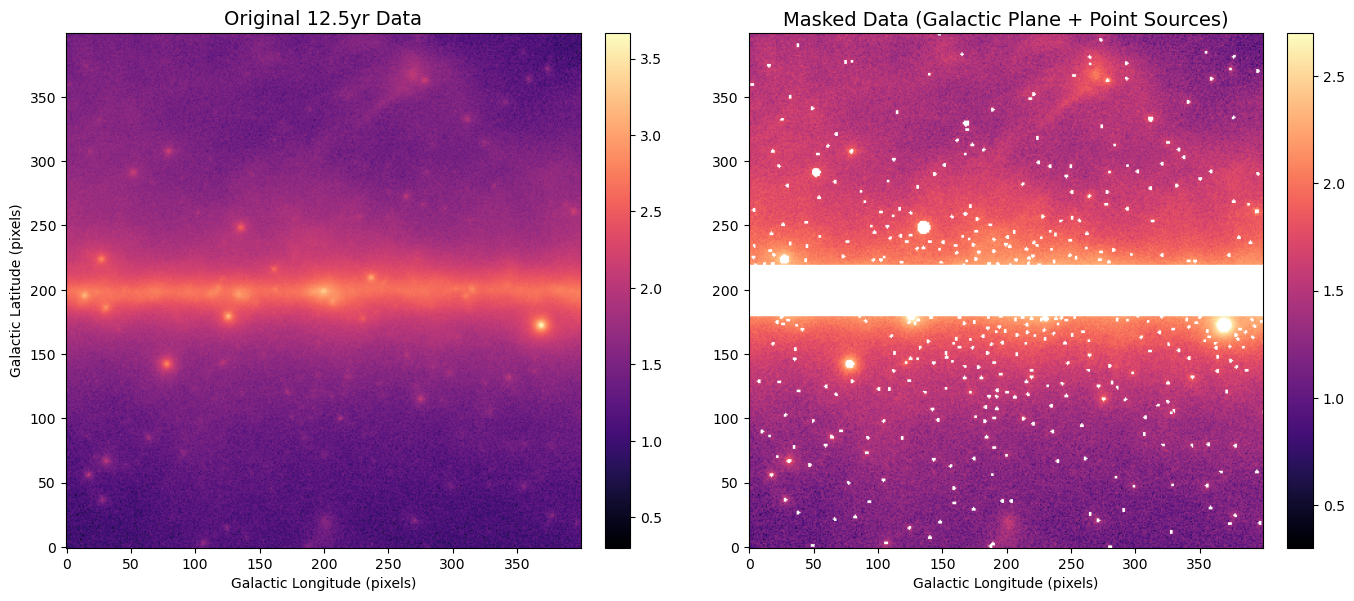

In [31]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
import copy

# 1. 실제 관측 데이터 (Data Map) 로드
data_hdul = fits.open('GCE_12yr_ccube.fits')
data_cube = data_hdul[0].data
data_map2d = np.sum(data_cube, axis=0)  # 에너지 축 합산

# 2. 동적 마스킹된 파일 로드 (은하 적도면 + 점광원)
mask_hdul = fits.open('GCE_12yr_mask_b2_and_pts.fits')
mask_2d = mask_hdul[0].data

# =======================================================
# 3. [핵심 수정] 실수형(float)으로 변환 후 NaN 할당
# =======================================================
masked_data_map2d = data_map2d.astype(float)  # 정수형을 실수형으로 변환
masked_data_map2d[mask_2d == 0] = np.nan      # 마스킹 된 곳을 NaN으로 변경

# 4. 시각화 세팅
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Magma 컬러맵을 복사해온 뒤, NaN 값(결측치)을 '하얀색(white)'으로 설정합니다!
cmap_with_white = copy.copy(plt.cm.magma)
cmap_with_white.set_bad(color='white')

# 원본 데이터 플롯
im1 = axes[0].imshow(np.log10(data_map2d + 1), origin='lower', cmap='magma')
axes[0].set_title('Original 12.5yr Data', fontsize=14)
axes[0].set_xlabel('Galactic Longitude (pixels)')
axes[0].set_ylabel('Galactic Latitude (pixels)')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# 마스킹된 데이터 플롯 (하얀색 구멍 확인)
im2 = axes[1].imshow(np.log10(masked_data_map2d + 1), origin='lower', cmap=cmap_with_white)
axes[1].set_title('Masked Data (Galactic Plane + Point Sources)', fontsize=14)
axes[1].set_xlabel('Galactic Longitude (pixels)')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# GCE 공간 템플릿은 없으나 표준 NFW profile을 사용한 것으로 보임
# Fermi Bubbles 공간 템플릿도 없으나 레퍼런스 78에 있는 fermi bubbles data를 표준으로 생각하여 참조했다고 함.